In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import copy
import random
import matplotlib.cm as cm
import matplotlib.colors as colors
import networkx as nx
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors
%run helper_functions.ipynb
plt.rcParams['font.family'] = 'Times New Roman'

### Functions

In [2]:
def sample_bounded_normal(mean, sd, min_val = 0, max_val = 1):
    result = np.random.normal(loc = mean, scale = sd, size=None)
    while result < min_val or result > max_val:
        result = np.random.normal(loc = mean, scale = sd, size=None)
    return result  

In [3]:
def row_normalize(matrix):
    row_sums = matrix.sum(axis=1, keepdims=True)
    # Replace zeros with ones to avoid division by zero
    safe_row_sums = np.where(row_sums == 0, 1, row_sums)
    return matrix / safe_row_sums

In [4]:
def get_influence_group(population, pop_structure, own_key, n):
    if pop_structure == 'well_mixed_group':
        neighbors = [key for key in population.keys() if key != own_key]
        return random.sample(neighbors, n)

    neighbors = population[own_key]['neighbors']
    if n <= len(neighbors):
        return random.sample(neighbors, n)
    else:
        return neighbors # May be empty 

In [5]:
def get_M(all_influence_keys, α): 
    N = len(all_influence_keys)
    M = np.zeros((N, N))
    for i in range(N):
        influence_group = all_influence_keys[i]
        for j in influence_group: # If influence_group is empty, will not run this part
            M[i, j] = 1 # Here, do not need to adjust by -1 since these indices go from 0 to N-1   

        if len(influence_group) == 0:
            M[i, i] = 1
        else:
            M[i, i] = α 
    row_sums = M.sum(axis=1, keepdims=True)
    normalized_M = M / row_sums
    return normalized_M

In [6]:
def sample_conform(x_vec, σ, α, d, min_val = 0, max_val = 1):
    """
    The first entry of x_vec must be one's own belief (not sorted). 
    """
    if α == 'max':
        return sample_bounded_normal(x_vec[0], σ, min_val, max_val)
    if len(x_vec) == 1:
        return sample_bounded_normal(x_vec[0], σ, min_val, max_val)
    if len(x_vec) == 2:
        weight_each_guess = [α, 1]
        weight_each_guess = [i/sum(weight_each_guess) for i in weight_each_guess]
        chosen_guess = random.choices(x_vec, weight_each_guess)[0]
        return sample_bounded_normal(chosen_guess, σ, min_val, max_val)
       
    weight_each_guess = [α] + [1]*(len(x_vec)-1)
    weight_each_guess = [i/sum(weight_each_guess) for i in weight_each_guess]
    
    if d != 0: # This is always true in our simulations. Otherwise, code will need to be revised 
        prob_social = prob_choose(x_vec, d, 2, 9) 
        prob_each_guess = [weight_each_guess[i]*prob_social[i] for i in range(len(prob_social))]
        prob_each_guess = [i/sum(prob_each_guess) for i in prob_each_guess]
    chosen_guess = random.choices(x_vec, prob_each_guess)[0]
    return sample_bounded_normal(chosen_guess, σ, min_val, max_val)

In [7]:
def update_opinion(population, model_type, pop_structure, n, σ, α, d):
    N = len(population)
    
    if model_type == 'conf':
        for key in population:
            x_vec = [population[key]['own opinion']] # Initialize with own opinion 
            if α != 'max':
                influence_group = get_influence_group(population, pop_structure, key, n)
                for influence_group_key in influence_group:
                    x_vec.append(population[influence_group_key]['own opinion']) 
            population[key]['revised opinion'] = sample_conform(x_vec, σ, α, d)
    
    elif 'fdg' in model_type: 
        s_vec = [entry['own opinion'] for entry in population.values()]
        all_influence_keys = []
        for key in population:
            influence_group = get_influence_group(population, pop_structure, key, n)
            all_influence_keys.append(influence_group)
        M = get_M(all_influence_keys, α)

        if model_type == 'fdg2':
            M_squared = M @ M
            result_before_error = M_squared @ s_vec
            new_σ_vec = σ * np.sqrt(np.sum(M_squared ** 2, axis=1)) 
        elif model_type == 'fdg1':
            result_before_error = M @ s_vec 
            new_σ_vec = σ * np.sqrt(np.sum(M ** 2, axis=1)) 
            
        for index, value in enumerate(result_before_error):
            population[index]['revised opinion'] = sample_bounded_normal(value, new_σ_vec[index])

In [8]:
def update_population(population, model_type, pop_structure, n, σ, α, d, num_groups = 1, m = None, ω = None):
    update_opinion(population, model_type, pop_structure, n, σ, α, d) 
    
    if pop_structure == 'adaptive_network':
        rewire_adaptive(population, ω, n)
    else:
        for key in population: 
            population[key]['own opinion'] = population[key]['revised opinion']
            population[key]['revised opinion'] = np.nan

In [9]:
def rewire_adaptive(population, ω, n=3):
    N = len(population)
    for i in range(N):
        own_opinion = population[i]['revised opinion']
        own_error = abs(own_opinion - ω)

        current_neighbors = population[i]['neighbors']
        new_neighbors = [j for j in current_neighbors if abs(population[j]['revised opinion'] - ω) <= own_error]

        potential_candidates = [k for k in range(N) if k != i and k not in current_neighbors]
        candidates = random.sample(potential_candidates, min(n, len(potential_candidates)))
        for j in candidates:
            candidate_error = abs(population[j]['revised opinion'] - ω)
            if candidate_error < own_error:
                new_neighbors.append(j)
        population[i]['neighbors'] = new_neighbors
    
    return population

In [10]:
def generate_network(population, ρ = 0.2):
    for key in population:
        population[key]['neighbors'] = []
    
    N = len(population)
    for own_key in range(N):
        for other_key in range(N):
            if (own_key != other_key) and (random.random() < ρ):
                    population[own_key]['neighbors'].append(other_key)

### Model options:

- `well_mixed_group`
- `static_network`
- `adaptive_network`

### Initial distribution options:

- `skewed = True` or `skewed = False`

In [11]:
N = 100
generations = 1000
pop_structure = 'adaptive_network' 
n = 3 
α = 2
σ = 0.08
d = 0.8 
skewed = False
num_replicates = 30
ω = 0.9 

### Set initial neighbors and opinions

In [12]:
np.random.seed(1)
random.seed(1)

init_pop = {i: {'own opinion': np.nan, 'revised opinion': np.nan} 
            for i in range(N)}

if pop_structure == 'well_mixed_group':
    for own_key in range(N):
        init_pop[own_key]['neighbors'] = [i for i in range(N) if i != own_key] 

if pop_structure in ['static_network', 'adaptive_network']:
    generate_network(init_pop) 

In [13]:
np.random.seed(1)
random.seed(1)

if pop_structure in ['well_mixed_group', 'static_network', 'adaptive_network']:
    if skewed:
        keys = list(init_pop.keys())
        np.random.shuffle(keys)
        for key in keys[:N//2]:
            init_pop[key]['own opinion'] = np.random.uniform(0, 0.2)
        for key in keys[N//2:]:
            init_pop[key]['own opinion'] = np.random.uniform(0.8, 1) 
    else:
        for key in range(N):
            init_pop[key]['own opinion'] = np.random.uniform(0, 1)  

if pop_structure == 'adaptive_network':
    for key in range(N):
        init_pop[key]['revised opinion'] = init_pop[key]['own opinion']

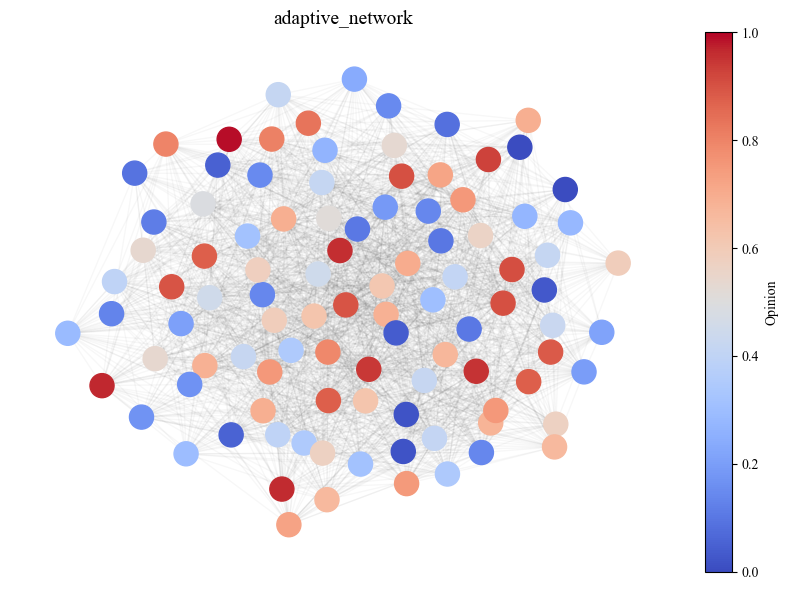

In [14]:
np.random.seed(1)
random.seed(1)
to_visualize = init_pop

G = nx.Graph()
for node_id, data in to_visualize.items():
    G.add_node(node_id, **data)  

for node_id, data in to_visualize.items():
    if 'neighbors' in data:
        for neighbor in data['neighbors']:
            G.add_edge(node_id, neighbor)

opinions = np.array([data['own opinion'] for _, data in G.nodes(data=True)])
norm = mcolors.Normalize(vmin=0, vmax=1)
cmap = plt.get_cmap('coolwarm')
node_colors = cmap(norm(opinions))

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42) 
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300)
nx.draw_networkx_edges(G, pos, alpha=0.03, arrowsize=10)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.046, pad=0.04)
cbar.set_label('Opinion')

plt.title(f"{pop_structure}", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('your-filename-here-1.png', bbox_inches = 'tight', dpi=300)
plt.show()

In [15]:
if pop_structure == 'well_mixed_group':
    for own_key in range(N):
        init_pop[own_key]['neighbors'] = [] # We know neighbors = everyone; do not need to slow down code

In [16]:
init_opinions = []
for i in range(N):
    init_opinions.append(init_pop[i]['own opinion'])

np.mean(init_opinions)

0.48587792760014564

### Run simulation

- Conformity model = `conf`
- One-stage French-DeGroot = `fdg1`
- Two-stage French-DeGroot = `fdg2`

In [17]:
start_time = time.time() 
replicate_results = {'conf': [], 'fdg1': [], 'fdg2': []}

for replicate in range(num_replicates):
    for model_type in ['conf', 'fdg1', 'fdg2']:
        population = copy.deepcopy(init_pop)
        
        avg_opinions = []
        polarization_indices = []

        avg_opinions.append(np.mean(init_opinions))
        denom = np.mean(init_opinions) * (1 - np.mean(init_opinions))
        polarization_indices.append(np.var(init_opinions) / denom)

        if pop_structure in ['well_mixed_group', 'static_network', 'adaptive_network']:
            replicate_results[model_type].append({
                'avg_opinions': avg_opinions,
                'polarization_indices': polarization_indices
            })

        for g in range(generations):
            if pop_structure in ['well_mixed_group', 'static_network']:
                update_population(population, model_type, pop_structure, n, σ, α, d)  
            elif pop_structure == 'adaptive_network':
                update_population(population, model_type, pop_structure, n, σ, α, d, 1, None, ω)

            if pop_structure == 'adaptive_network':
                all_opinions = [population[key]['revised opinion'] for key in population]
            else:
                all_opinions = [population[key]['own opinion'] for key in population]
            avg_opinions.append(np.mean(all_opinions))

            denom = np.mean(all_opinions) * (1 - np.mean(all_opinions))
            polarization_indices.append(np.var(all_opinions) / denom)

        if pop_structure in ['well_mixed_group', 'static_network', 'adaptive_network']:
            replicate_results[model_type].append({
                'avg_opinions': avg_opinions,
                'polarization_indices': polarization_indices
            })

end_time = time.time()
print("Time: " + str((end_time-start_time)/60) + " minutes.")

Time: 3.8203442970911663 minutes.


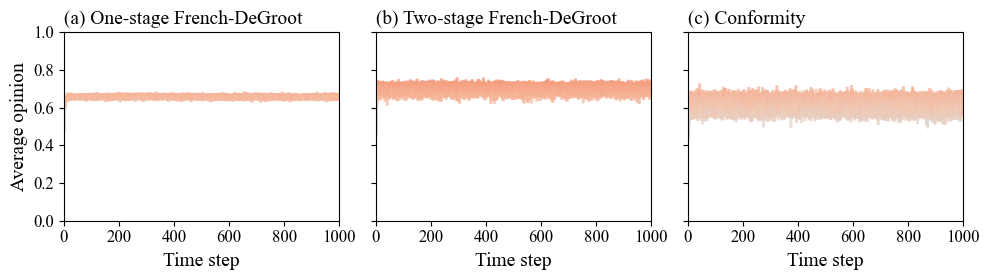

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(10, 2.9), sharey=True)
model_types = ['fdg1', 'fdg2', 'conf']
cmap = plt.get_cmap('coolwarm')
norm = mcolors.Normalize(vmin=0, vmax=1)

for ax, model_type in zip(axes, model_types):
    for rep in replicate_results[model_type]:
        y_vals = np.array(rep['avg_opinions'])
        x_vals = np.arange(len(y_vals))

        points = np.array([x_vals, y_vals]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        colors = cmap(norm(y_vals[:-1]))
        lc = LineCollection(segments, colors=colors, linewidths=2, alpha=0.3)
        ax.add_collection(lc)

    ax.tick_params(axis='both', labelsize=12)
    ax.set_ylim([0, 1])
    ax.set_xlim([0, generations])
    ax.set_xlabel('Time step', fontsize=14)

    if model_type == 'fdg1':
        ax.set_title('(a) One-stage French-DeGroot', fontsize=14, loc='left')
    elif model_type == 'fdg2':
        ax.set_title('(b) Two-stage French-DeGroot', fontsize=14, loc='left')
    elif model_type == 'conf':
        ax.set_title('(c) Conformity', fontsize=14, loc='left')

axes[0].set_ylabel('Average opinion', fontsize=14)
plt.tight_layout()
plt.savefig('your-filename-here-2.png', bbox_inches='tight', dpi=300)
plt.show()

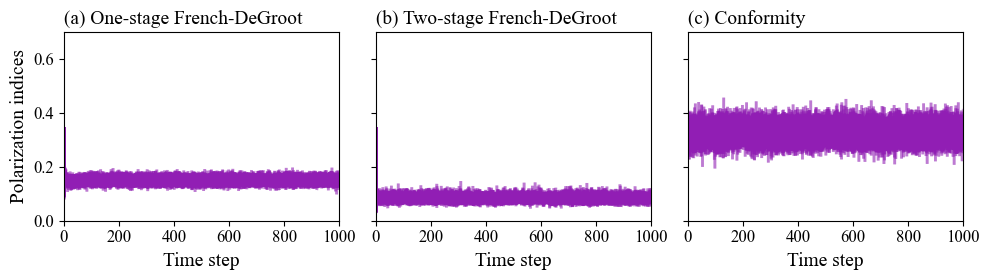

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(10, 2.9), sharey=True)
model_types = ['fdg1', 'fdg2', 'conf']
cmap = plt.get_cmap('coolwarm')
norm = mcolors.Normalize(vmin=0, vmax=1)

for ax, model_type in zip(axes, model_types):
    for rep in replicate_results[model_type]:
        y_vals = np.array(rep['polarization_indices'])
        x_vals = np.arange(len(y_vals))

        points = np.array([x_vals, y_vals]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        colors = cmap(norm(y_vals[:-1]))
        lc = LineCollection(segments, colors='#911eb4', linewidths=2, alpha=0.2)
        ax.add_collection(lc)

    ax.tick_params(axis='both', labelsize=12)
    ax.set_ylim([0, 0.7])
    ax.set_xlim([0, 1000])
    ax.set_xlabel('Time step', fontsize=14)

    if model_type == 'fdg1':
        ax.set_title('(a) One-stage French-DeGroot', fontsize=14, loc='left')
    elif model_type == 'fdg2':
        ax.set_title('(b) Two-stage French-DeGroot', fontsize=14, loc='left')
    elif model_type == 'conf':
        ax.set_title('(c) Conformity', fontsize=14, loc='left')

axes[0].set_ylabel('Polarization indices', fontsize=14)
plt.tight_layout()
plt.savefig('your-filename-here-3.png', bbox_inches='tight', dpi=300)
plt.show()